# 11: Regional Competitive Position

**Business question**: Earlier notebooks in this project focus on Johor specifically. But is Johor actually a fair stand-in for Malaysia's regional position, or does using it understate the real picture? And is Malaysia's own power grid showing strain from carrying this load?

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/dcboom.db')
regional = pd.read_sql_query("SELECT * FROM regional_comparison ORDER BY capacity_mw DESC", conn)
conn.close()
regional

,market,capacity_mw,regime_note
0,Malaysia (national),2055.0,"End-2026 estimate, all states combined (Johor ..."
1,Singapore,1400.0,Operational across 70+ facilities. Moratorium ...
2,Johor,850.0,"Built; +1,800MW building, +2,700MW pipeline. R..."
3,Indonesia (national/Batam),580.0,~1.3GW pipeline (~$15-20bn investment). Batam'...
4,Vietnam,525.0,Forecast to reach 950.4MW by 2030
5,Thailand,135.0,One estimate's 2030 capacity target; smallest ...


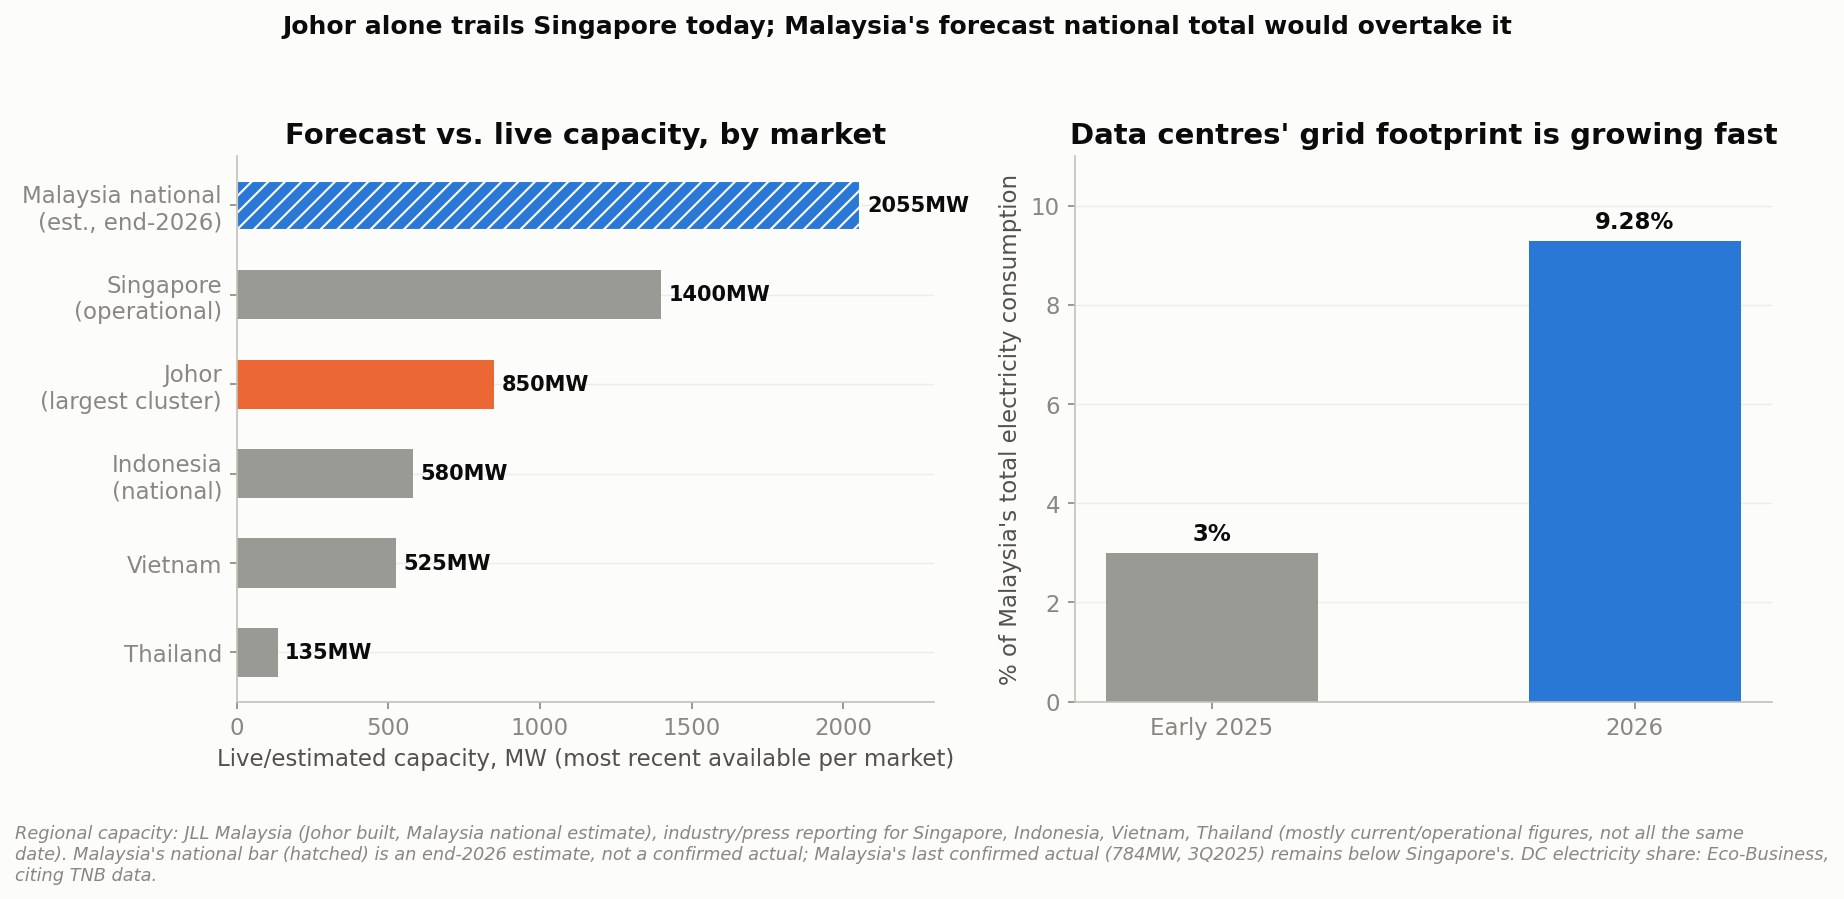

In [2]:
from IPython.display import Image
Image(filename='../outputs/figures/11_regional_position.png')

## A real gap in how this project framed itself, corrected here

Notebooks 1, 2, 7, and 10 all focus on Johor, for a good reason: it is the single largest, most concentrated cluster, and its border-adjacent "overflow valve" relationship with Singapore is a genuinely distinct story. But this project's own contractor data (Notebook 6) shows major hyperscale construction happening well outside Johor too, in Selangor and Negeri Sembilan, together accounting for roughly two-thirds of the confirmed contractor-dollar value found in this project. **Using Johor alone to represent "Malaysia" in a country-to-country comparison understates Malaysia's actual position**, and this notebook corrects that instead of repeating the same framing a third time.

Here are the two comparisons this project can actually make, kept separate on purpose:

- **Johor vs. Singapore, today**: Johor (850MW built) is smaller than Singapore (~1.4GW operational), and stays smaller under any reasonable reading of the numbers.
- **Malaysia vs. Singapore, by end-2026**: Malaysia's national total is *estimated* to reach 2,055MW by end-2026 (Notebook 2). If that estimate holds, Malaysia as a whole country would pass Singapore's current capacity. But it's an estimate for a few months from now, not something that has already happened: Malaysia's last confirmed actual figure (784MW, as of the third quarter of 2025) is still below Singapore's.

So: Johor specifically is behind Singapore and stays there. Malaysia as a country is on track to pull ahead soon, but hasn't confirmed it yet. Both statements are true at the same time, and this project states both rather than picking whichever sounds better. **[PUBLIC, JLL Malaysia data centre market report for both the Johor and Malaysia national figures; industry/press reporting for Singapore's capacity]**

None of this changes the earlier notebooks' Johor-specific findings, which remain accurate for what they claim. It does mean a reader who took Johor's numbers as a stand-in for the whole country, as this project's own earlier framing invited, would have gotten a smaller and slightly outdated picture than the real one. **[Disclosed limitation, corrected in this notebook rather than left standing]**

Elsewhere in the region, Indonesia's national market (including the Batam data centre corridor, with a notable 511MVA/~450MW power purchase agreement for the DayOne project, phased 2026-2027) sits at roughly **580MW**, Vietnam at **525MW** (forecast to reach 950MW by 2030), and Thailand at a smaller **135MW** target for 2030. Malaysia's growth rate, whether measured by Johor alone or nationally, is faster than any of these three markets, though all are earlier-stage than either Malaysia or Singapore.

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/dcboom.db')
capacity = pd.read_sql_query("SELECT year, malaysia_live_mw, johor_built_mw FROM capacity_trend WHERE year = 2026", conn)
conn.close()
capacity['rest_of_malaysia_implied_mw'] = capacity['malaysia_live_mw'] - capacity['johor_built_mw']
capacity['johor_share_pct'] = (capacity['johor_built_mw'] / capacity['malaysia_live_mw'] * 100).round(1)
capacity

,year,malaysia_live_mw,johor_built_mw,rest_of_malaysia_implied_mw,johor_share_pct
0,2026,2055.0,850.0,1205.0,41.4


## Where the 2,055MW national estimate actually comes from

That 2,055MW figure isn't just a number handed down from a report with no way to check it. This project can account for most of it directly. Johor's own built capacity (850MW) makes up **41.4% of the national total on its own**, leaving **1,205MW for the rest of Malaysia**. That remaining 1,205MW lines up with something this project already found independently, in Notebook 6, before ever comparing it to this national figure: at least six confirmed hyperscale data centre construction contracts in Selangor and Negeri Sembilan, worth a combined RM8.45 billion, found from Bursa Malaysia contract announcements. Two separate pieces of evidence, one a national estimate from a market report, one this project's own hand-collected contract data, point the same way. **[DERIVED, this project's own cross-check of the JLL estimate against its own Notebook 6 findings]**

This project can't break the remaining 1,205MW down further than that (JLL doesn't publish its full methodology, and there may be smaller clusters elsewhere, like older facilities around Cyberjaya or Penang, that this project didn't separately count). So this is a corroborated estimate, not a fully audited one. But it's a real, checkable number now, not a figure the reader just has to take on trust.

## Independent evidence the grid is feeling this, beyond TNB's own framing

Data centres' share of Malaysia's total electricity consumption rose from roughly **3% in the first nine months of 2025 to 9.28% by 2026**, a genuinely fast trajectory independent of TNB's own investor-relations framing. **[PUBLIC, Eco-Business, citing TNB data]** This is worth reading alongside Notebook 4's separate figure of **7% for 2026**, drawn from the government's own JPPPET planning forecast: the two numbers measure different things (JPPPET's is a forecast share of total electricity *demand*, a planning document produced ahead of time; this figure is actual measured *consumption*, reported closer to real time) and are not directly comparable, but the gap is close enough, and both point the same direction fast enough, that it is also consistent with actual growth outpacing the government's own forecast, a possibility this project cannot confirm from the two sources alone but flags rather than silently presenting two similar-looking numbers as if they were interchangeable. **[Disclosed limitation: two similarly-scoped figures from different sources were not fully reconciled]**

As of September 2025, TNB had signed **49 Electricity Supply Agreements with data centre developers, totalling 7.1GW of future demand, with 29 of those (3.8GW) already connected**, equivalent to roughly 13% of Peninsular Malaysia's total system capacity at that point. **[PUBLIC, TransitionZero analysis citing TNB data]** This September 2025 snapshot predates the 2Q FY2026 figures in Notebook 3 (61 projects, 8.35GW secured, 5.65GW connected) by about a year, consistent with, not contradictory to, the growth trajectory shown there, just an earlier data point along the same trend.

Grid operators themselves, not just TNB's investor-relations materials, have voiced real operational concern. Named officials from TNB and its Grid System Operator have described data centres as **"a new animal"** requiring new flexibility tools like battery storage and demand response, with one GSO official, Rofidah Mohamad, stating plainly: **"We cannot manage what we cannot see."** **[PUBLIC, quoted directly in independent press reporting]** This project could not verify a separately-circulating claim about a multi-year pause in new gas-fired power capacity (a source article returned a fetch error); that specific claim is excluded rather than passed through unverified. **[Disclosed limitation: one claim could not be verified and was deliberately excluded]**

## Explain It Simply

Most of this project has talked about Johor specifically, because it's the single biggest cluster and has a genuinely interesting story about spilling over from Singapore next door. But it's worth being honest: Johor is not the same thing as Malaysia. Real hyperscale data centre construction is also happening in Selangor and Negeri Sembilan, roughly 41% of Malaysia's estimated national total is Johor, and the rest lines up with real construction contracts this project found in those other two states. Once you add all of Malaysia together, the country's total capacity is forecast to overtake Singapore's by the end of 2026, not still catching up to it the way "Johor vs Singapore" alone made it look, though that's a forecast for a few months from now, not something that has definitely happened yet. So there are really two different, true answers here: Johor specifically is smaller than Singapore today and stays that way; Malaysia as a whole country is on track to pull ahead soon, not there yet for certain. Both matter, depending on whether you're asking about the border corridor or the country.

## Glossary

- **Power Usage Effectiveness (PUE)**: a measure of a data centre's energy efficiency, the ratio of total facility energy use to energy used by the actual computing equipment; a lower number is more efficient.
- **Renewable Energy Certificate (REC)**: a tradable certificate representing proof that one unit of electricity was generated from a renewable source, used to demonstrate a facility's clean-energy credentials.
- **Demand response**: a grid-management technique where large customers agree to reduce their electricity use during periods of peak system stress, in exchange for compensation or lower rates.

## Why Is This Happening?

**Why would Singapore choose to constrain a booming, high-value industry within its own borders?** Singapore is a small, dense city-state with genuinely scarce land and water, and a strong existing policy commitment to a specific national carbon and sustainability trajectory; unconstrained data centre growth would compete directly with these other priorities in a way that a much larger, less land-constrained neighbour does not face to the same degree. Johor, sitting immediately across a land border with cheaper resources and a government actively courting this investment (Notebook 1), was always the most natural pressure-release valve for demand that Singapore's own policy was never going to fully satisfy, which is exactly the pattern the capacity numbers in this notebook show playing out.

---
**Sources**: Industry and press reporting on Singapore's Data Centre Call for Application rounds and its 2019-2022 moratorium; JLL Malaysia data centre market report (Johor and Malaysia national capacity figures); this project's own Notebook 6 contractor data (for the Selangor/Negeri Sembilan share of confirmed contracts); industry/press reporting for Indonesia (including the DayOne/Batam project), Vietnam, and Thailand capacity figures; Eco-Business, citing TNB data (Malaysia's DC electricity-consumption share); TransitionZero analysis citing TNB data (September 2025 ESA snapshot); independent press reporting quoting named TNB/Grid System Operator officials. All figures are **PUBLIC**, sourced to independent press or industry reporting rather than a single company's own materials; the "overflow valve" framing, the Johor-vs-national distinction, and the cross-market growth-rate comparison are this project's own, classified **DERIVED**.